In [46]:
import pandas as pd
import geopandas as gpd
import numpy as np

In [47]:
nfdb = pd.read_csv("../data/NFDB_point.csv")
evac = pd.read_csv("../data/Canadian_Wildfire_Evacuation_Data.csv")
reserves = gpd.read_file("../data/AL_TA_CA_SHP_eng.zip")

In [48]:
nfdb.columns

Index(['FID', 'the_geom', 'NFDBFIREID', 'SRC_AGENCY', 'NAT_PARK', 'FIRE_ID',
       'FIRENAME', 'LATITUDE', 'LONGITUDE', 'YEAR', 'MONTH', 'DAY', 'REP_DATE',
       'OUT_DATE', 'SIZE_HA', 'CAUSE', 'FIRE_TYPE', 'RESPONSE', 'PROTZONE',
       'MORE_INFO'],
      dtype='str')

In [49]:
evac.columns

Index(['EvacID', 'Year', 'Province', 'Location', 'Lat', 'Long', 'Population',
       'PopulationNotes', 'FN_Reserve', 'EvacSize', 'IssueDate', 'EndDate',
       'EvacReason', 'Region', 'Group', 'FireSource', 'RepDOY', 'FireIgnit',
       'FireSize'],
      dtype='str')

In [50]:
reserves.columns

Index(['ACQTECH', 'METACOVER', 'CREDATE', 'REVDATE', 'ACCURACY', 'PROVIDER',
       'DATASETNAM', 'SPECVERS', 'NID', 'ALCODE', 'LANGUAGE1', 'NAME1',
       'LANGUAGE2', 'NAME2', 'LANGUAGE3', 'NAME3', 'LANGUAGE4', 'NAME4',
       'LANGUAGE5', 'NAME5', 'JUR1', 'JUR2', 'JUR3', 'JUR4', 'ALTYPE',
       'WEBREF', 'geometry'],
      dtype='str')

In [51]:
reserves = reserves[reserves["ALTYPE"] == "Indian Reserve"].copy()

## Add FN tags to fires

In [52]:
nfdb_gdf = gpd.GeoDataFrame(
    nfdb,
    geometry=gpd.points_from_xy(nfdb["LONGITUDE"], nfdb["LATITUDE"]),
    crs="EPSG:4326"
)

In [53]:
metric_crs = "EPSG:3347"

nfdb_m = nfdb_gdf.to_crs(metric_crs)
reserves_m = reserves.to_crs(metric_crs)

In [54]:
within = gpd.sjoin(
    nfdb_m[["geometry"]],
    reserves_m[["geometry"]],
    how="left",
    predicate="intersects"
)

nfdb_m["FN_indicator"] = within["index_right"].notna().to_numpy()

In [55]:
nearest = gpd.sjoin_nearest(
    nfdb_m[["geometry"]],
    reserves_m[["geometry"]],
    how="left",
    distance_col="dist_m"
)

nfdb_m["dist_to_FN_km"] = nearest["dist_m"].to_numpy() / 1000

In [56]:
nfdb_m["FN_indicator"].value_counts()
nfdb_m["dist_to_FN_km"].describe()

count    15206.000000
mean       142.409138
std        223.401005
min          0.000000
25%         25.250381
50%         54.868754
75%        172.877887
max       8959.330768
Name: dist_to_FN_km, dtype: float64

In [57]:
def count_within(points, polygons, radius_km):
    buffered = points[["geometry"]].copy()
    buffered["geometry"] = buffered.geometry.buffer(radius_km * 1000)

    joined = gpd.sjoin(
        buffered,
        polygons[["NID", "geometry"]],
        how="left",
        predicate="intersects"
    )

    counts = joined.groupby(joined.index)["NID"].nunique()
    return counts.reindex(points.index, fill_value=0)

In [58]:
nfdb_m["n_FN_20km"] = count_within(nfdb_m, reserves_m, 20)
nfdb_m["n_FN_50km"] = count_within(nfdb_m, reserves_m, 50)
nfdb_m["n_FN_100km"] = count_within(nfdb_m, reserves_m, 100)

In [59]:
nfdb_m["REP_DATE"] = pd.to_datetime(nfdb_m["REP_DATE"], errors="coerce")
evac["IssueDate"] = pd.to_datetime(evac["IssueDate"], errors="coerce")
evac["EndDate"] = pd.to_datetime(evac["EndDate"], errors="coerce")

## Add Evacs to fires

In [60]:
evac["IssueDate"] = pd.to_datetime(evac["IssueDate"], errors="coerce")
nfdb["REP_DATE"] = pd.to_datetime(nfdb["REP_DATE"], errors="coerce")

evac_gdf = gpd.GeoDataFrame(
    evac.copy(),
    geometry=gpd.points_from_xy(evac["Long"], evac["Lat"]),
    crs="EPSG:4326"
)

evac_m = evac_gdf.to_crs("EPSG:3347")

In [61]:
time_window_days = 14
max_dist_km = 100

matches = []

for i, evac_row in evac_m.iterrows():
    cand = nfdb_m[
        (nfdb_m["REP_DATE"] >= evac_row["IssueDate"] - pd.Timedelta(days=time_window_days)) &
        (nfdb_m["REP_DATE"] <= evac_row["IssueDate"] + pd.Timedelta(days=time_window_days))
    ].copy()

    if cand.empty:
        continue

    dists_m = cand.geometry.distance(evac_row.geometry)
    j = dists_m.idxmin()
    d_km = dists_m.loc[j] / 1000

    if d_km <= max_dist_km:
        matches.append({
            "EvacID": evac_row["EvacID"],
            "fire_idx": j,
            "match_dist_km": d_km,
            "FN_Reserve": evac_row["FN_Reserve"],
            "EvacSize": evac_row["EvacSize"],
            "Population": evac_row["Population"],
            "IssueDate": evac_row["IssueDate"],
            "EndDate": evac_row["EndDate"],
            "Province": evac_row["Province"],
            "Location": evac_row["Location"],
        })

matches = pd.DataFrame(matches)
matches["IssueDate"] = pd.to_datetime(matches["IssueDate"], errors="coerce")
matches["EndDate"] = pd.to_datetime(matches["EndDate"], errors="coerce")

In [62]:
matches["evac_duration_days"] = (
    pd.to_datetime(matches["EndDate"]) - pd.to_datetime(matches["IssueDate"])
).dt.days

fire_evac = matches.groupby("fire_idx").agg(
    n_evac=("EvacID", "count"),
    any_evac=("EvacID", lambda x: True),
    n_FN_evac=("FN_Reserve", lambda x: (x == 1).sum()),
    total_evac_size=("EvacSize", "sum"),
    total_population=("Population", "sum"),
    mean_match_dist_km=("match_dist_km", "mean"),
    mean_evac_duration_days=("evac_duration_days", "mean"),
).reset_index()

In [63]:
nfdb_final = nfdb_m.merge(
    fire_evac,
    left_index=True,
    right_on="fire_idx",
    how="left"
)

nfdb_final["any_evac"] = nfdb_final["any_evac"].fillna(False)

for col in ["n_evac", "n_FN_evac", "total_evac_size", "total_population"]:
    nfdb_final[col] = nfdb_final[col].fillna(0)

In [64]:
nfdb_final["any_evac"].value_counts()

any_evac
False    14675
True       531
Name: count, dtype: int64

In [65]:
counts = matches["fire_idx"].value_counts()

print((counts > 1).sum(), "fires have multiple evacs")
counts.describe()

130 fires have multiple evacs


count    531.000000
mean       1.414313
std        0.918213
min        1.000000
25%        1.000000
50%        1.000000
75%        1.000000
max        8.000000
Name: count, dtype: float64

In [66]:
counts[counts > 1].head()

fire_idx
3445     8
2542     8
7462     6
2543     6
13546    5
Name: count, dtype: int64

In [67]:
matches["match_dist_km"].describe()

count    751.000000
mean      25.897826
std       24.270544
min        0.140385
25%        7.113892
50%       18.182206
75%       36.199341
max       98.180501
Name: match_dist_km, dtype: float64

Text(0.5, 0, 'Distance (km)')

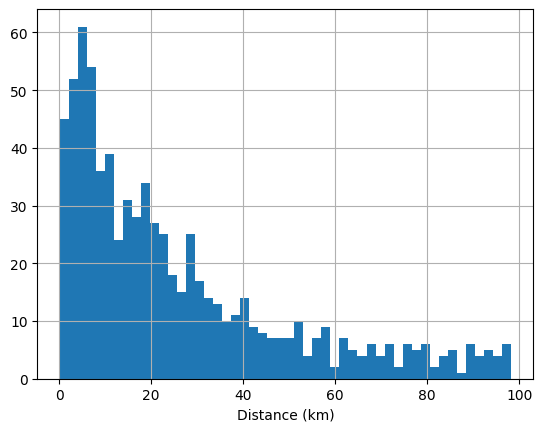

In [68]:
import matplotlib.pyplot as plt

matches["match_dist_km"].hist(bins=50)
plt.xlabel("Distance (km)")

In [69]:
total_evac = len(evac)
total_evac

1043

In [70]:
matched_evac = matches["EvacID"].nunique()
matched_evac

751

In [71]:
lost = total_evac - matched_evac
lost, lost / total_evac

(292, 0.2799616490891659)

In [72]:
evac["FN_Reserve_num"] = (
    evac["FN_Reserve"]
    .astype(str)
    .str.strip()
    .str.lower()
    .isin(["1", "true", "yes", "y"])
    .astype(int)
)

evac["matched"] = evac["EvacID"].isin(matches["EvacID"])
evac.groupby("matched")["FN_Reserve_num"].mean()

matched
False    0.284247
True     0.392810
Name: FN_Reserve_num, dtype: float64

### Final Columns

In [73]:
keep_cols = [
    # original fire info
    "NFDBFIREID", "SRC_AGENCY", "FIRE_ID", "FIRENAME",
    "LATITUDE", "LONGITUDE", "YEAR", "MONTH", "DAY",
    "REP_DATE", "OUT_DATE", "SIZE_HA", "CAUSE", "FIRE_TYPE",
    "RESPONSE", "PROTZONE",

    # FN features
    "FN_indicator", "dist_to_FN_km", "n_FN_20km", "n_FN_50km", "n_FN_100km",

    # matched evac features
    "any_evac", "n_evac", "n_FN_evac",
    "total_evac_size", "total_population",
    "mean_match_dist_km", "mean_evac_duration_days",
]

fire_db = nfdb_final[keep_cols].copy()

In [74]:
fire_db["REP_DATE"] = pd.to_datetime(fire_db["REP_DATE"], errors="coerce")
fire_db["OUT_DATE"] = pd.to_datetime(fire_db["OUT_DATE"], errors="coerce")

bool_cols = ["FN_indicator", "any_evac"]
for c in bool_cols:
    fire_db[c] = fire_db[c].fillna(False).astype(bool)

num_cols = [
    "dist_to_FN_km", "n_FN_20km", "n_FN_50km", "n_FN_100km",
    "n_evac", "n_FN_evac", "total_evac_size", "total_population",
    "mean_match_dist_km", "mean_evac_duration_days", "SIZE_HA"
]
for c in num_cols:
    fire_db[c] = pd.to_numeric(fire_db[c], errors="coerce")

In [75]:
fire_db = fire_db.rename(columns={
    'NFDBFIREID': 'nfdb_fire_id',
    'SRC_AGENCY': 'province',
    'FIRE_ID': 'fire_id',
    'FIRENAME': 'fire_name',
    'LATITUDE': 'latitude',
    'LONGITUDE': 'longitude',
    'YEAR': 'year',
    'MONTH': 'month',
    'DAY': 'day',
    'REP_DATE': 'report_date',
    'OUT_DATE': 'out_date',
    'SIZE_HA': 'fire_size_ha',
    'CAUSE': 'fire_cause',
    'FIRE_TYPE': 'fire_type',
    'RESPONSE': 'response_type',
    'PROTZONE': 'protection_zone',

    'FN_indicator': 'fn_indicator',
    'dist_to_FN_km': 'dist_to_fn_km',
    'n_FN_20km': 'n_fn_20km',
    'n_FN_50km': 'n_fn_50km',
    'n_FN_100km': 'n_fn_100km',

    'any_evac': 'any_evacuation',
    'n_evac': 'n_evacuations',
    'n_FN_evac': 'n_fn_evacuations',
    'total_evac_size': 'total_evacuation_size',
    'total_population': 'total_population',

    'mean_match_dist_km': 'mean_match_distance_km',
    'mean_evac_duration_days': 'mean_evacuation_duration_days',
})

In [76]:
df = fire_db.copy()
df = df[[
    # fire/geo info
    'province', 
    'latitude',
    'longitude',           
    # 'year',
    # 'month',
    'fire_size_ha',
    'fire_cause',
    'fire_type',
    'response_type',
    'protection_zone',

    # First Nations features
    'fn_indicator',
    'dist_to_fn_km',
    'n_fn_20km',
    # 'n_fn_50km',
    # 'n_fn_100km',

    'any_evacuation', # target
]]

In [77]:
df['fire_cause'] = df['fire_cause'].replace({
    'H': 'human',
    'H-PB': 'human_prescribed_burn',
    'N': 'natural',
    'U': 'unknown'
})

In [78]:
df['response_type'] = df['response_type'].replace({
    # full suppression
    'FUL': 'full',
    'SUP': 'full',
    'PRO': 'full',
    'Actioned': 'full',

    # moderate / limited
    'MOD': 'moderate',
    'MDP': 'moderate',
    'Limited Action': 'moderate',

    # monitored
    'MON': 'monitor',
    'MNP': 'monitor',

}).fillna('other')

In [79]:
df['fire_type'] = (
    df['fire_type']
    .str.lower()
    .str.strip()
)

In [80]:
df['protection_zone'] = (
    df['protection_zone']
    .str.lower()
    .str.strip()
)

In [81]:
df['protection_zone_clean'] = 'other'

df.loc[df['protection_zone'].str.contains('intensive|ful|full'), 'protection_zone_clean'] = 'intensive'

df.loc[df['protection_zone'].str.contains('transitional|transition'), 'protection_zone_clean'] = 'transitional'

df.loc[df['protection_zone'].str.contains('strategic|stratigic'), 'protection_zone_clean'] = 'strategic'

df.loc[df['protection_zone'].str.contains('wilderness|low priority|observation'), 'protection_zone_clean'] = 'wilderness'

df.loc[df['protection_zone'].str.contains('nordique'), 'protection_zone_clean'] = 'nordique'

df.loc[df['protection_zone'].str.contains('mod'), 'protection_zone_clean'] = 'moderate'

df.loc[df['protection_zone'].str.contains('mon'), 'protection_zone_clean'] = 'monitor'

In [82]:
df['protection_zone'] = df['protection_zone_clean']
df = df.drop(columns=['protection_zone_clean'])

In [83]:
df['fire_type'] = df['fire_type'].fillna('unknown')
df['response_type'] = df['response_type'].fillna('unknown')
df['protection_zone'] = df['protection_zone'].fillna('unknown')

In [ ]:
df['log_fire_size_ha'] = np.log1p(df['fire_size_ha'])
df['log_dist_to_fn_km'] = np.log1p(df['dist_to_fn_km'])

df['log_fire_size_ha'] = (df['log_fire_size_ha'] - df['log_fire_size_ha'].mean()) / df['log_fire_size_ha'].std()
df['log_dist_to_fn_km'] = (df['log_dist_to_fn_km'] - df['log_dist_to_fn_km'].mean()) / df['log_dist_to_fn_km'].std()
df.drop(columns=['fire_size_ha', 'dist_to_fn_km'], inplace=True)

In [86]:
df.to_csv("../data/fire_db.csv", index=False)

In [87]:
df = pd.read_csv("../data/fire_db.csv")

### Trim 3 problematic rows

In [88]:
bad = np.array([593, 10422, 13359])
df_clean = df.drop(index=bad).reset_index(drop=True)

In [89]:
df.iloc[bad]

,province,latitude,longitude,fire_cause,fire_type,response_type,protection_zone,fn_indicator,n_fn_20km,any_evacuation,log_fire_size_ha,log_dist_to_fn_km
593,NL,52.34592,61.07878,natural,unknown,other,other,False,0,False,-1.317279,3.264608
10422,YT,0.00000,0.00000,unknown,unknown,other,other,False,0,False,-0.987422,3.465100
13359,PC,0.00000,0.00000,human_prescribed_burn,unknown,other,other,False,0,False,-1.076803,3.465100


In [90]:
df_clean.to_csv("../data/fire_db.csv", index=False)

In [91]:
df_clean

,province,latitude,longitude,fire_cause,fire_type,response_type,protection_zone,fn_indicator,n_fn_20km,any_evacuation,log_fire_size_ha,log_dist_to_fn_km
0,BC,49.301400,-119.709100,human,fire,full,other,False,10,False,0.103451,-1.434898
1,BC,52.035100,-123.177000,human,fire,full,other,True,7,False,-1.335084,-2.821013
2,BC,53.288400,-120.070500,human,fire,full,other,False,0,False,-0.287845,0.671645
3,BC,52.254800,-120.835200,human,fire,full,other,False,0,False,-1.285883,-0.243862
4,BC,49.311500,-122.243800,human,fire,moderate,other,False,11,False,-1.317279,-0.808326
...,...,...,...,...,...,...,...,...,...,...,...,...
15198,AB,57.408000,-113.496000,natural,surface,other,other,False,0,False,-0.232896,-0.234751
15199,AB,57.552983,-115.553983,unknown,ground,other,other,False,0,False,-1.217843,-0.689793
15200,AB,56.859183,-119.659367,natural,surface,other,other,False,0,False,1.468147,-0.198970
15201,AB,55.022167,-115.897500,natural,crown,other,other,False,0,False,-0.744007,-0.386046
